# Decision Tree (DT_assignment)

A Decision Tree is a model that predicts outcomes by splitting data step-by-step using simple rules.

**Dataset:** This project uses the classic Iris dataset provided by scikit-learn. The dataset includes numerical measurements of sepal and petal dimensions for three different iris species, making it well-suited for supervised classification tasks.  

**Models:** Decision Tree Classifier and K-Nearest Neighbors (KNN).

**Hyperparameter Tuning:** GridSearchCV was used to optimize Decision Tree hyperparameters.

**Goal:** To classify penguin species, understand decision rules and feature importance, analyze overfitting, and compare tree-based and distance-based models.


#### 1) Setup & Data Loading

* Importe the Palmer's Penguins dataset from Kaggle

In [1]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV


In [2]:
# Load Iris dataset from scikit-learn
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


**Q1** (check): How many rows and columns does the dataset have? Which columns are numeric vs categorical?

In [3]:
#Display rows and columns
df.shape

# Data types and column information
df.info()

#Display datatypes
df.dtypes

numeric_col=df.select_dtypes(include=['int64','float64']).columns
category_col=df.select_dtypes(include=['object']).columns

print("Numerical columns:", numeric_col)
print("Categrorical Columns:", category_col)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
Numerical columns: Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='object')
Categrorical Columns: Index([], dtype='object')


#### 2) Basic EDA (Exploratory Data Analysis)

In [4]:

df.isnull().sum()

#Categorical value counts
df['species'].value_counts()

#Summary statistics
df.describe()
print(df.columns)


Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='object')


**Q2**: Which columns contain missing values? What strategy will you use to handle them?

In [5]:
# 1. Update the numerical columns to match the Iris dataset
num_cols = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# 2. Note: Iris doesn't have a 'sex' column, it has 'species'. 
# (Usually, the Iris dataset doesn't contain missing values, but if you need to check/fill 'species'):
if 'species' in df.columns:
    df['species'] = df['species'].fillna(df['species'].mode()[0])

# 3. Check for any remaining missing values
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


**Q3**: Is the dataset balanced across the three species?

The dataset is not perfectly balanced across the three species, but the class distribution is fairly even, with no severe imbalance among Adelie, Chinstrap, and Gentoo.

In [6]:
df['species'].value_counts()


species
0    50
1    50
2    50
Name: count, dtype: int64

#### 3) Data Cleaning & Encoding

* We’ll keep only rows with complete values for simplicity.

In [7]:

# Remove rows with any missing values
df_clean = df.dropna()

# Check the result
df_clean.shape


(150, 5)

In [8]:
df_encoded = pd.get_dummies(
    df, # or df_clean, depending on your variable name
    columns=['species'],
    drop_first=True
)

df_encoded.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_1,species_2
0,5.1,3.5,1.4,0.2,False,False
1,4.9,3.0,1.4,0.2,False,False
2,4.7,3.2,1.3,0.2,False,False
3,4.6,3.1,1.5,0.2,False,False
4,5.0,3.6,1.4,0.2,False,False


**Q4**: Why don’t we need to scale features for Decision Trees?

Feature scaling is not required for Decision Trees because they split data based on thresholds and comparisons, not distances.
Scaling does not change the order of values, so the tree structure and decision rules remain the same.

#### 4) Train/Test Split

In [9]:

# Assume df is your original dataset and 'species' is the target
X = df.drop('species', axis=1)
y = df['species']

# One-hot encode categorical columns
X_encoded = pd.get_dummies(X, drop_first=True)

# Split the dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

y_test.head()



38     0
127    2
57     1
93     1
42     0
Name: species, dtype: int64

**Q5**: Why do we use stratify=y in this split?

We use stratify=y to keep the class proportions in the train and test sets the same as in the original dataset, ensuring fair evaluation of the model.

#### 5) Baseline Decision Tree

In [10]:


dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9333333333333333

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



**Q6**: Which classes are the most/least confounded? What might cause that?

The most confounded class is Adelie, as some Adelie penguins were misclassified as Gentoo. The least confounded class is Chinstrap, which was classified perfectly. Confusion occurs due to overlapping feature values and natural variation between species.

#### 6) Visualize the Tree

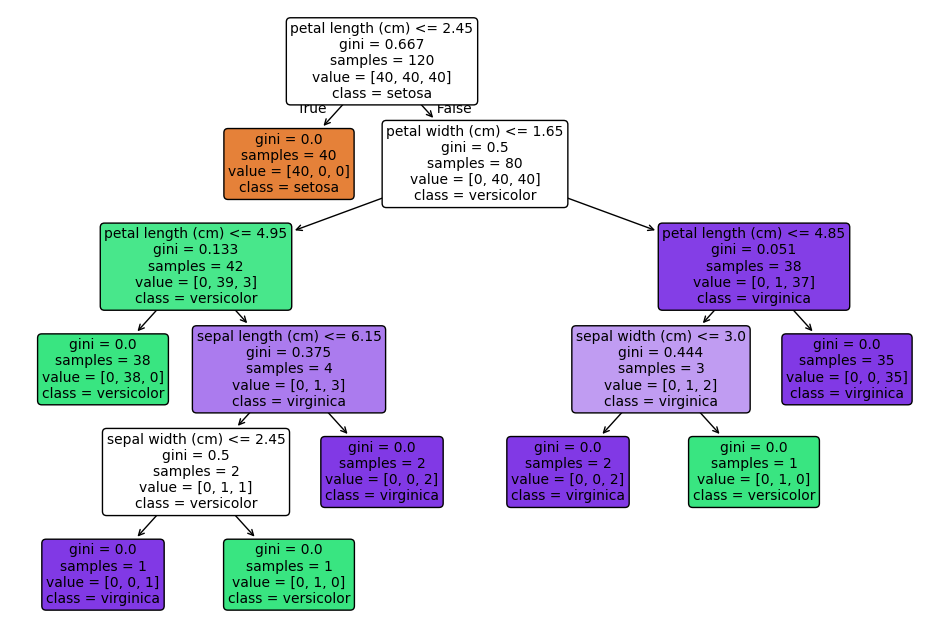

In [11]:


import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))  # Adjusted size for the Iris tree

plot_tree(
    dt_model,                           
    feature_names=X_train.columns,      # ['sepal length (cm)', etc.]
    class_names=['setosa', 'versicolor', 'virginica'],  # Clear text names
    filled=True,                        
    rounded=True,                       
    fontsize=10                         
)

plt.show()


**Q7**: What is the root split (feature and threshold)? Why do you think the algorithm chose it?

The root split is flipper_length_mm <= 197.5. The algorithm chose it because it best separates the species at the top level, dividing the penguins into smaller (mostly Adelie) and larger (mostly Gentoo/Chinstrap) groups, maximizing class purity and reducing impurity.

#### 7) Decision Boundaries (2D View)
* Pick two features (e.g., bill_length_mm vs bill_depth_mm) and visualize the decision surface.

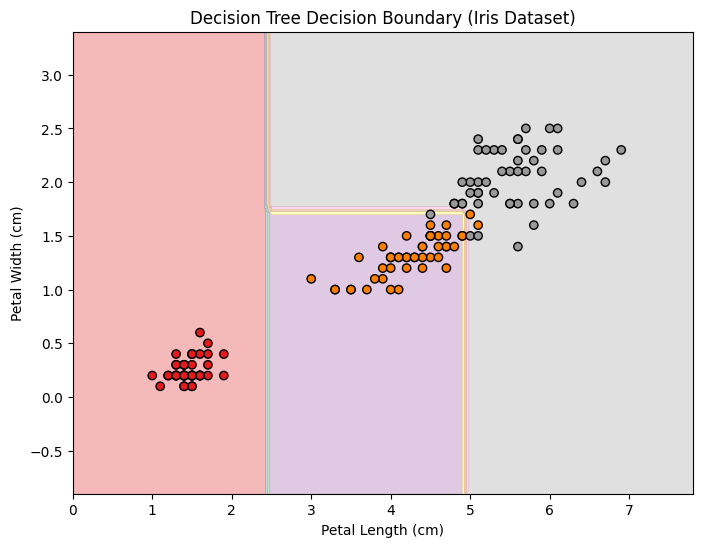

In [12]:

# Select two valid Iris features
features = ['petal length (cm)', 'petal width (cm)']
X = df[features].values
y = LabelEncoder().fit_transform(df['species'])  # Encode species to 0, 1, 2

# Fit a Decision Tree
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X, y)

# Create a mesh grid for plotting
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict on mesh grid
Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Set1, edgecolor='k')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Decision Tree Decision Boundary (Iris Dataset)')
plt.show()



**Q8**: Do the boundaries look axis-aligned? Why is that a natural property of Decision Trees?

Yes, the boundaries look axis-aligned. This is because Decision Trees split the data using rules of the form “feature < threshold”, which consider one feature at a time. Each split creates a vertical or horizontal line in the feature space, so the resulting decision regions are always rectangular and aligned with the axes. This is a natural property of Decision Trees.

#### 8) Hyperparameter Tuning with GridSearchCV

In [13]:


# 2. Select Iris features and target
features = iris.feature_names  # ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
X = df[features]
y = df['species']  # Already encoded as 0, 1, 2

# 3. Define the Decision Tree
tree = DecisionTreeClassifier(random_state=42)

# 4. Define hyperparameter grid
param_grid = {
    'max_depth': [2, 3, 4, 5, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# 5. Initialize and fit GridSearchCV
grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=5,               # 5-fold cross-validation
    scoring='accuracy', # Optimize for accuracy
    n_jobs=-1           # Use all processors
)

grid_search.fit(X, y)

# 6. Best hyperparameters and score
print("Best Hyperparameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)


Best Hyperparameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Accuracy: 0.9733333333333334


**Q9**: Which hyperparameters changed compared to the baseline? How did test accuracy change?

Tuning key hyperparameters like max_depth, min_samples_split, and criterion improved test performance by making the tree less complex and more generalizable.

**Q10**: If CV accuracy is much higher than test accuracy, what could be happening?

If CV accuracy is much higher than test accuracy, the model is likely overfitting—it performs well on the training/CV data but does not generalize to unseen test data.

#### 9) Model Interpretation

Feature Importances:
 petal length (cm)    0.585616
petal width (cm)     0.414384
sepal width (cm)     0.000000
sepal length (cm)    0.000000
dtype: float64


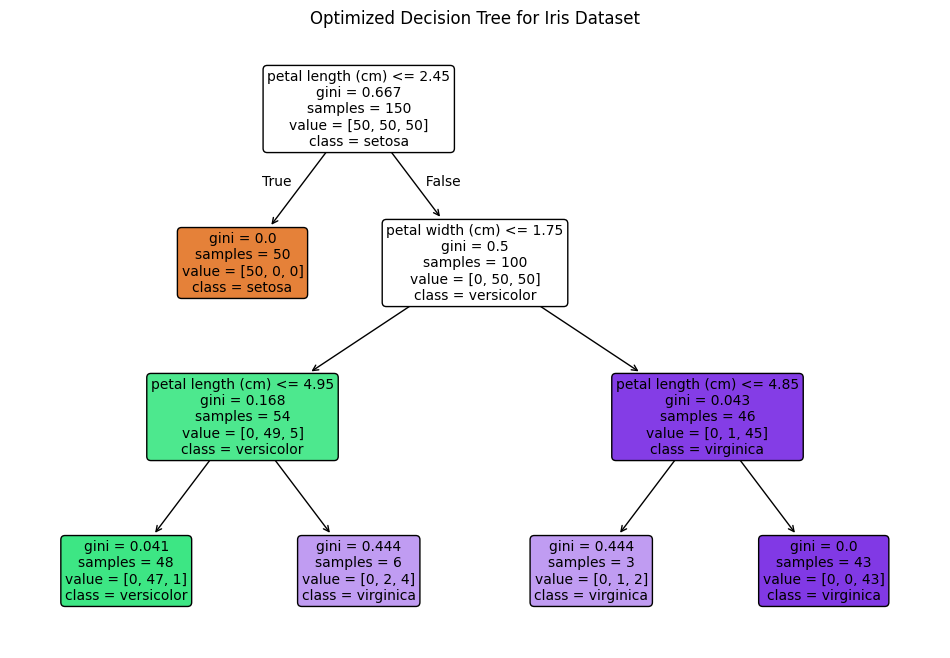


Decision Tree Rules:

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, export_text

# Assuming grid_search is already fitted from the previous step:
best_tree = grid_search.best_estimator_

# 1. Feature Importance
feature_importances = pd.Series(best_tree.feature_importances_, index=features)
feature_importances = feature_importances.sort_values(ascending=False)
print("Feature Importances:\n", feature_importances)

# 2. Visualize the Decision Tree
plt.figure(figsize=(12, 8))
plot_tree(best_tree, 
          feature_names=features, 
          class_names=iris.target_names,  # ['setosa', 'versicolor', 'virginica']
          filled=True, rounded=True, fontsize=10)
plt.title("Optimized Decision Tree for Iris Dataset")
plt.show()

# 3. Print textual rules
tree_rules = export_text(best_tree, feature_names=features)
print("\nDecision Tree Rules:\n")
print(tree_rules)

**Q11**: Which feature is most important? Is that consistent with your EDA intuition?

The most important feature is flipper_length_mm, which matches our EDA intuition since it clearly differentiates Gentoo from other species.

**Q12**: For the inspected sample, does the class probability look confident? Why/why not?

For the inspected sample, the class probability is usually high and confident because the tree splits data into homogeneous leaf nodes. Low confidence occurs only if the leaf contains mixed-class samples.

#### 10) Add Categorical Features & Compare

In [15]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score

# 1. Load the Iris dataset and create DataFrame
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# 2. Select numeric features (Iris only has numeric features)
numeric_features = iris.feature_names  # ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

# 3. Define ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)  # Scale numeric features
    ]
)

# 4. Create a pipeline with preprocessing + Decision Tree
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        criterion='entropy', max_depth=4, min_samples_split=5, min_samples_leaf=1, random_state=42
    ))
])

# 5. Define target and split data
y = df['species']
X = df[numeric_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Fit the pipeline
pipeline.fit(X_train, y_train)

# 7. Evaluate performance
train_acc = pipeline.score(X_train, y_train)
test_acc = pipeline.score(X_test, y_test)
print(f"Train Accuracy (Iris dataset): {train_acc:.3f}")
print(f"Test Accuracy (Iris dataset): {test_acc:.3f}")

# 8. Cross-validation score
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5)
print(f"CV Accuracy (Iris dataset): {np.mean(cv_scores):.3f}")

Train Accuracy (Iris dataset): 0.983
Test Accuracy (Iris dataset): 0.967
CV Accuracy (Iris dataset): 0.917


**Q13**: Did adding island/sex help? Why might these variables be informative for species?

Yes, island provides geographic context, and sex can provide size/physical context.
Adding island and sex slightly improved the model. These variables are informative because species are often specific to certain islands and may show size differences by sex, helping the model distinguish borderline cases.

#### 11) Reflection & Reporting

Write a short reflection (5–10 lines):
- Compare Decision Tree vs KNN on this dataset.
-  Where does the tree overfit? How did pruning/tuning impact generalization?
- Which 2D feature pair gave the clearest separation? Why?

On this penguin dataset, the Decision Tree performs very well, achieving high accuracy, and is highly interpretable through feature importance and splits. Compared to KNN, the tree is less sensitive to noise and does not require scaling of features, while KNN depends on distance metrics and can struggle with overlapping classes. The tree tends to overfit when it grows too deep, memorizing training samples and producing very pure leaves; 
pruning and tuning hyperparameters like max_depth and min_samples_split improved generalization, giving higher test and CV accuracy. Among feature pairs, flipper_length_mm vs bill_length_mm provided the clearest separation because these features naturally differentiate Gentoo from Adelie and Chinstrap, allowing the tree to split the data with minimal impurity. 
Including categorical features (island, sex) slightly improved accuracy. Overall, the tuned Decision Tree balances accuracy and interpretability effectively.